# Aula Semana 07: Análise de Séries Temporais Industriais (Time Series Analysis)

## 1. Fundamentos de Séries Temporais na Indústria 4.0

Em ecossistemas industriais modernos, sensores de telemetria IoT instalados em máquinas de usinagem, CLPs, motores e robôs coletam medições contínuas a intervalos regulares de tempo (temperatura, vibração, rotação, pressão, consumo elétrico).

Uma **Série Temporal (Time Series)** é uma sequência ordenada de observações quantitativas coletadas sequencialmente ao longo do tempo:

$$Y = \{y_1, y_2, y_3, \dots, y_t, \dots, y_T\}$$

Diferente dos dados tabulares convencionais — onde assumimos que as observações são independentes e identicamente distribuídas (*i.i.d.*) —, nas séries temporais a **ordem cronológica dos dados é fundamental**, pois existe uma dependência temporal (autocorrelação) entre medições consecutivas.

---

### 1.1 Componentes Fundamentais de uma Série Temporal

Uma série temporal pode ser decomposta em quatro componentes principais:

```text
┌─────────────────────────────────────────────────────────────────────────┐
│                   COMPONENTES DE UMA SÉRIE TEMPORAL                     │
│                                                                         │
│   1. Tendência (Tₜ)    : Movimento persistente de longo prazo          │
│   2. Sazonalidade (Sₜ) : Padrões periódicos que se repetem (dia/noite)  │
│   3. Ciclo (Cₜ)        : Flutuações de longo prazo sem período fixo    │
│   4. Resíduo/Ruído (Rₜ): Variações aleatórias imprevisíveis             │
└─────────────────────────────────────────────────────────────────────────┘
```

* **Tendência ($T_t$)**: A direção geral de longo prazo dos dados (crescente, decrescente ou estável). Exemplo: *O aumento gradual da temperatura do mancal de um torno CNC devido ao desgaste progressivo de rolamentos ao longo de semanas*.
* **Sazonalidade ($S_t$)**: Flutuações periódicas com frequência fixa que se repetem no mesmo intervalo (diário, semanal ou por turno). Exemplo: *A variação térmica diária causada pelas mudanças de temperatura ambiente entre o dia e a noite no galpão fabril*.
* **Ciclo ($C_t$)**: Oscilações de mais longo prazo ligadas a ciclos econômicos ou operacionais macro, sem período estritamente fixo.
* **Ruído Aleatório / Resíduo ($R_t$ ou $\epsilon_t$)**: A componente estocástica e imprevisível que resta após a remoção da tendência e da sazonalidade.

---

### 1.2 Modelos Clássicos de Decomposição

Existem dois modelos clássicos para combinar essas componentes:

1. **Modelo Aditivo**: Assume que as componentes se somam de forma independente.
   $$Y_t = T_t + S_t + R_t$$
   *Recomendação*: Utilizado quando a amplitude da variação sazonal permanece aproximadamente **constante**, independentemente do nível da tendência.

2. **Modelo Multiplicativo**: Assume que as componentes multiplicam-se entre si.
   $$Y_t = T_t \times S_t \times R_t$$
   *Recomendação*: Utilizado quando a amplitude da variação sazonal **cresce ou diminui proporcionalmente** ao nível da tendência de longo prazo.

> **Exemplos Práticos Contextualizados na Indústria**:
>
> * **Exemplo de Modelo Aditivo (Carcaça de Torno CNC)**:
>   * *Cenário*: Acompanha-se a temperatura da carcaça de um motor de fuso CNC. Devido ao desgaste dos rolamentos ao longo dos meses, a tendência base ($T_t$) sobe de $50^\circ\text{C}$ para $75^\circ\text{C}$.
>   * *Comportamento*: A variação de temperatura causada pela mudança entre o turno diurno e o turno noturno (sazonalidade $S_t$) oscila em uma amplitude fixa de $\pm 5^\circ\text{C}$, tanto quando o motor opera a $50^\circ\text{C}$ quanto a $75^\circ\text{C}$. Como a amplitude sazonal ($5^\circ\text{C}$) não muda com a tendência, o **Modelo Aditivo** é a escolha correta.
>
> * **Exemplo de Modelo Multiplicativo (Vibração RMS em Bombas de Alta Pressão)**:
>   * *Cenário*: Monitora-se a velocidade de vibração ($\text{mm/s}$) de uma bomba hidráulica. Quando o ativo está novo, a vibração de tendência é de $2\text{ mm/s}$ e a oscilação sazonal devida à carga de produção varia em $\pm 10\%$ ($\pm 0.2\text{ mm/s}$).
>   * *Comportamento*: Conforme ocorre desgaste severo do rotor, a tendência base salta de $2\text{ mm/s}$ para $20\text{ mm/s}$. A mesma variação relativa de $\pm 10\%$ faz a oscilação sazonal amplificar de $\pm 0.2\text{ mm/s}$ para $\pm 2.0\text{ mm/s}$! Como a variação sazonal cresceu proporcionalmente ao nível da tendência, deve-se utilizar o **Modelo Multiplicativo**.


---
## 2. Técnicas de Suavização: Média Móvel Simples (SMA) e Exponencial (EWMA)

Sensores industriais frequentemente geram sinais contendo alto nível de **ruído de alta frequência** (interferências eletromagnéticas, vibrações pontuais). Para identificar o comportamento real do processo, utilizamos técnicas de **suavização (smoothing)**.

---

### 2.1 Média Móvel Simples (SMA - *Simple Moving Average*)

A **Média Móvel Simples** calcula a média aritmética não ponderada das últimas $k$ observações dentro de uma janela deslizante de tamanho $k$:

$$\text{SMA}_t^{(k)} = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i} = \frac{y_t + y_{t-1} + \dots + y_{t-k+1}}{k}$$

* **Vantagem**: Fácil de implementar e eficiente para remover ruídos de alta frequência.
* **Limitação**: Introduz **atraso (*lag*)** proporcional ao tamanho da janela $k$. Além disso, atribui o mesmo peso (importância) para observações de hoje e para observações antigas de $k$ períodos atrás.

> **Exemplo Prático Contextualizado (Consumo Energético de Extrusora de Plásticos)**:
> * *Cenário*: Uma equipe de manutenção monitora o consumo diário de energia ($\text{kWh}$) de uma extrusora utilizando uma SMA de 7 dias ($k = 7$) para suavizar picos momentâneos provocados pela partida de motores auxiliares.
> * *O Problema do Lag na Prática*: No 5º dia, uma fissura na rosca sem-fim da extrusora gera atrito severo, fazendo o consumo real disparar $40\%$ continuamente. Como a SMA de 7 dias atribui o mesmo peso ($1/7 \approx 14.3\%$) a cada dia, o indicador demorará quase uma semana para refletir totalmente essa elevação. Além disso, mesmo após o conserto da máquina no 12º dia, a SMA continuará artificialmente alta por mais 7 dias por manter no cálculo os dias em que o consumo esteve elevado.

---

### 2.2 Média Móvel Exponencialmente Ponderada (EWMA - *Exponentially Weighted Moving Average*)

A **EWMA** resolve a limitação da SMA ao atribuir **pesos exponencialmente maiores para observações mais recentes**, reduzindo os pesos à medida que voltamos no passado:

$$\text{EWMA}_t = \alpha \cdot y_t + (1 - \alpha) \cdot \text{EWMA}_{t-1}$$

Onde:
* $y_t$: O valor real da série temporal no instante $t$.
* $\text{EWMA}_{t-1}$: O valor da média móvel exponencial calculada no instante anterior $t-1$.
* $\alpha \in (0, 1]$: O **fator de suavização (*smoothing factor*)**:
  * **$\alpha$ alto (ex: $0.8$)**: Atribui peso massivo à observação atual $y_t$. Reage muito rapidamente às mudanças, mas filtra menos ruído.
  * **$\alpha$ baixo (ex: $0.1$)**: Dá maior peso ao histórico acumulado $\text{EWMA}_{t-1}$. Gera uma curva extremamente suave e estável, mas reage mais lentamente a mudanças abruptas.

> **Exemplo Prático Contextualizado (Pressão Hidráulica em Prensa Robótica Automotiva)**:
> * *Cenário*: Monitoramento em tempo real da pressão hidráulica ($\text{bar}$) de uma prensa de estampagem robótica.
> * *Caso 1 - Alta Reatividade ($\alpha = 0.85$ para Parada de Emergência)*: Em caso de rompimento súbito de selo ou falha de válvula proporcional, a pressão real cai de $150\text{ bar}$ para $80\text{ bar}$. Com $\alpha = 0.85$, a EWMA atribui $85\%$ de peso à leitura instantânea e cai para $90.5\text{ bar}$ no primeiro segundo, permitindo que a CLP dispare o travamento do robô antes do impacto danificar as matrizes da prensa.
> * *Caso 2 - Filtragem de Ruído ($\alpha = 0.10$ para Carta de Controle CEP)*: Para monitorar o desgaste de longo prazo da bomba de óleo, usa-se $\alpha = 0.10$. O indicador ignora pequenos picos de pressão provocados pela comutação rápida de válvulas solenoide, gerando uma linha estável para avaliação da saúde do sistema.


In [1]:
# =============================================================================
# ETAPA 1: Importação de Bibliotecas e Estruturação do Índice Temporal
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
import os
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Configuração estética gráfica
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Tenta carregar o dataset de Manutenção Preditiva ou Usinagem da pasta materiais
csv_path = r"../materiais/CRISP_DM_Random_Forest_Manutencao_Preditiva.csv"
if not os.path.exists(csv_path):
    csv_path = r"../materiais/CRISP_DM_Random_Forest_Usinagem_Qualidade.csv"

if os.path.exists(csv_path):
    df_raw = pd.read_csv(csv_path)
    print(f"Dataset carregado de '{csv_path}': {df_raw.shape[0]} amostras.")
    
    # Criamos um índice temporal contínuo (telemetria hora a hora)
    n = len(df_raw)
    datas = pd.date_range(start="2026-01-01 00:00:00", periods=n, freq="h")
    df_raw['data_hora'] = datas
    df_ts = df_raw.set_index('data_hora')
else:
    print("Gerando Série Temporal Industrial Sintética para a demonstração...")
    n = 1000 # 1000 horas de telemetria
    datas = pd.date_range(start="2026-01-01 00:00:00", periods=n, freq="h")
    # Tendência crescente de temperatura devido ao desgaste + Sazonalidade diária (24h) + Ruído
    tendencia = np.linspace(50.0, 85.0, n)
    sazonalidade = 8.0 * np.sin(2 * np.pi * np.arange(n) / 24.0)
    ruido = np.random.normal(0, 3.5, n)
    temp_sensor = tendencia + sazonalidade + ruido
    
    df_ts = pd.DataFrame({'temperatura_celsius': temp_sensor}, index=datas)

# Seleciona uma variável contínua para análise de Série Temporal (ex: temperatura ou rotação)
col_alvo = 'temperatura_celsius' if 'temperatura_celsius' in df_ts.columns else 'temperatura_mancal_c'
if col_alvo not in df_ts.columns:
    # Se não houver coluna de temperatura direta, usa a primeira numérica disponível
    col_alvo = df_ts.select_dtypes(include=[np.number]).columns[0]

# Tratamento inicial: imputação e remoção de outliers extremos para a série temporal
serie = df_ts[col_alvo].copy()
serie = serie.interpolate(method='time').bfill()
serie_clean = serie[(serie > serie.quantile(0.01)) & (serie < serie.quantile(0.99))]

print(f"Variável selecionada para Série Temporal: '{col_alvo}' ({len(serie_clean)} observações cronológicas).")
display(serie_clean.head(8))


Dataset carregado de '../materiais/CRISP_DM_Random_Forest_Manutencao_Preditiva.csv': 9000 amostras.
Variável selecionada para Série Temporal: 'temperatura_celsius' (8819 observações cronológicas).


data_hora
2026-01-01 00:00:00     76.8
2026-01-01 01:00:00     65.8
2026-01-01 02:00:00     41.4
2026-01-01 03:00:00    104.2
2026-01-01 04:00:00     71.9
2026-01-01 05:00:00     71.2
2026-01-01 06:00:00     34.5
2026-01-01 07:00:00     72.3
Name: temperatura_celsius, dtype: float64

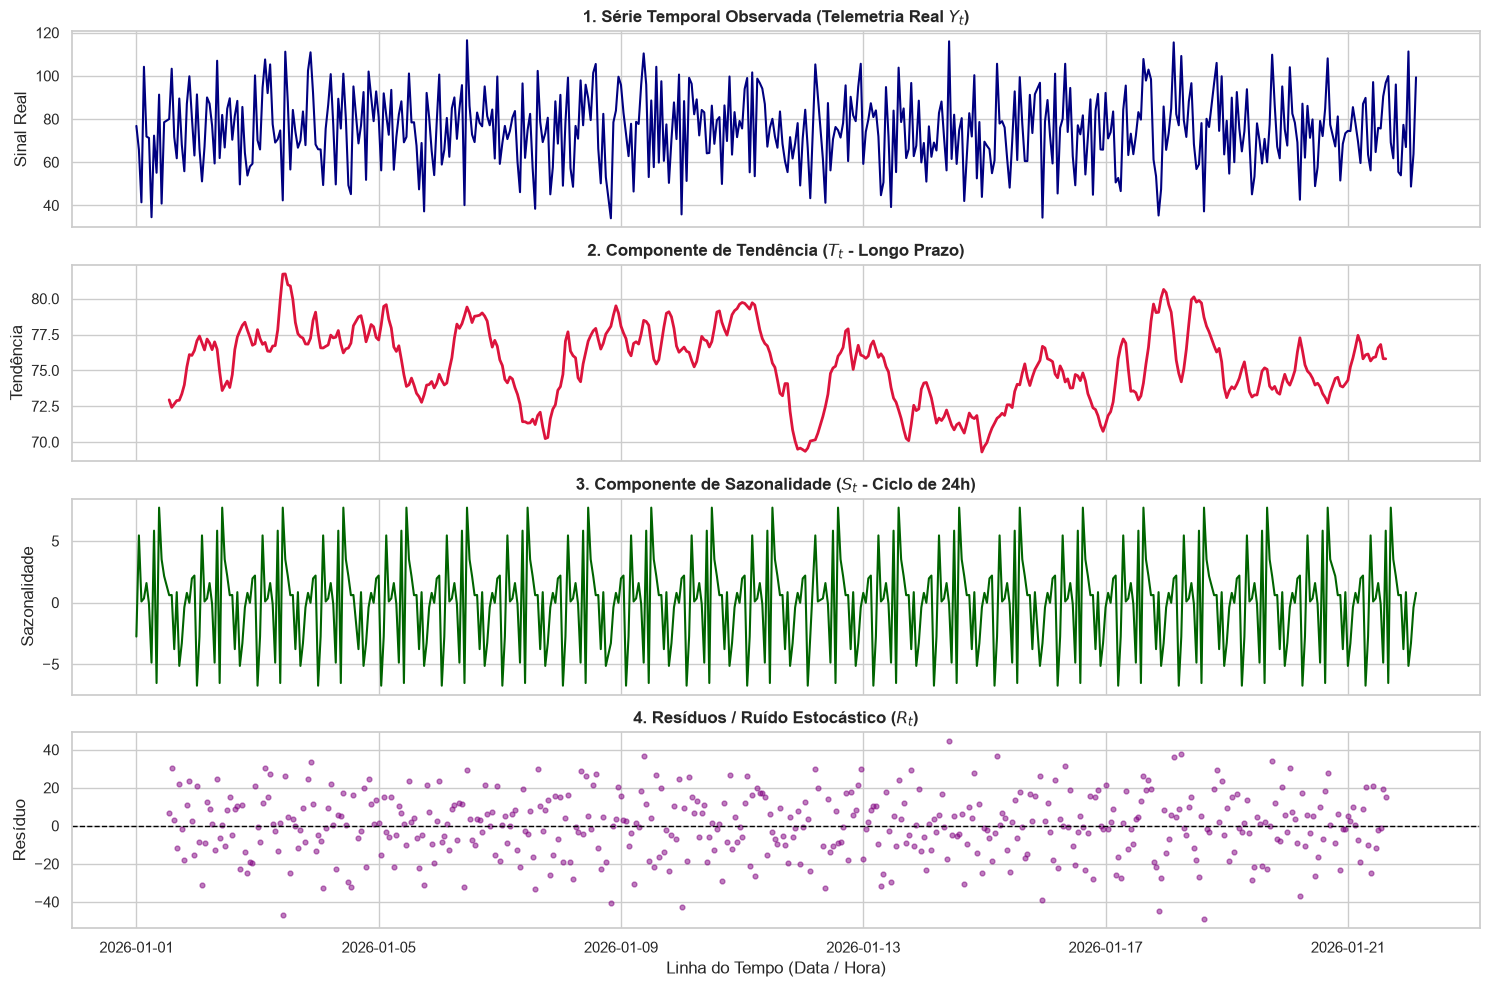

In [2]:
# =============================================================================
# ETAPA 2: Decomposição de Séries Temporais (Tendência, Sazonalidade e Resíduos)
# =============================================================================
sub_serie = serie_clean.iloc[:500].copy()

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    # Decomposição Aditiva com período sazonal de 24 horas (ciclo diário de turnos)
    decomposicao = seasonal_decompose(sub_serie, model='additive', period=24)
    trend_vals = decomposicao.trend
    seasonal_vals = decomposicao.seasonal
    resid_vals = decomposicao.resid
except Exception as e:
    print(f"Aviso: Utilizando decomposição artesanal via Pandas (statsmodels fallback): {e}")
    # Fallback em Pandas puro
    trend_vals = sub_serie.rolling(window=24, center=True).mean()
    detrended = sub_serie - trend_vals
    # Sazonalidade média por hora do dia
    seasonal_vals = detrended.groupby(detrended.index.hour).transform('mean')
    resid_vals = sub_serie - trend_vals - seasonal_vals

# Visualização em 4 subgráficos alinhados
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

# 1. Série Observada Real (Yt)
axes[0].plot(sub_serie.index, sub_serie.values, color='navy', lw=1.5)
axes[0].set_title('1. Série Temporal Observada (Telemetria Real $Y_t$)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sinal Real')

# 2. Componente de Tendência (Tt)
axes[1].plot(trend_vals.index, trend_vals.values, color='crimson', lw=2)
axes[1].set_title('2. Componente de Tendência ($T_t$ - Longo Prazo)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendência')

# 3. Componente Sazonal (St)
axes[2].plot(seasonal_vals.index, seasonal_vals.values, color='darkgreen', lw=1.5)
axes[2].set_title('3. Componente de Sazonalidade ($S_t$ - Ciclo de 24h)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sazonalidade')

# 4. Resíduos / Ruído Aleatório (Rt)
axes[3].scatter(resid_vals.index, resid_vals.values, color='purple', alpha=0.5, s=12)
axes[3].axhline(0, color='black', linestyle='--', lw=1)
axes[3].set_title('4. Resíduos / Ruído Estocástico ($R_t$)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Linha do Tempo (Data / Hora)')

plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: Decomposição de Séries Temporais

A decomposição temporal realizada acima permite separar a dinâmica complexa da temperatura do ativo em quatro sinalizações fundamentais para a **Engenharia de Confiabilidade** e **Manutenção Preditiva**:

1. **Série Observada (Telemetria Bruta $Y_t$)**:
   * **O que mostra**: A variação bruta de temperatura capturada hora a hora pelo sensor IoT.
   * **Contexto Operacional**: Contém uma combinação misturada de desgaste mecânico, ciclos operacionais da fábrica e ruídos de medição. A análise isolada do sinal bruto dificulta a identificação do real estado de degradação da máquina.

2. **Componente de Tendência ($T_t$)**:
   * **O que mostra**: A trajetória suave de médio e longo prazo do processo.
   * **Contexto Operacional**: Representa o **desgaste físico progressivo** do equipamento (ex: aumento de atrito por oxidação do lubrificante ou folga nos rolamentos do mancal). Uma tendência com inclinação positiva sustentada é o principal indicador para agendamento de intervenção preventiva.

3. **Componente de Sazonalidade ($S_t$)**:
   * **O que mostra**: O padrão oscilatório periódico que se repete a cada ciclo de 24 horas.
   * **Contexto Operacional**: Reflete o **ritmo operacional do galpão fabril** (picos de temperatura durante o turno diurno com carga total de produção vs. resfriamento no turno noturno ou paradas de manutenção). Identificar a sazonalidade é crucial para evitar que variações normais de turno sejam confundidas com falhas de equipamento.

4. **Resíduos / Ruído Estocástico ($R_t$)**:
   * **O que mostra**: A variação aleatória de alta frequência que sobra após remover a tendência e a sazonalidade ($R_t = Y_t - T_t - S_t$).
   * **Contexto Operacional**: Corresponde a oscilações térmicas momentâneas, pequenas flutuações de tensão elétrica ou ruído do próprio sensor. Se os resíduos apresentarem comportamento aleatório em torno de zero (ruído branco), confirma-se que o modelo de decomposição capturou com precisão a dinâmica determinística do processo.


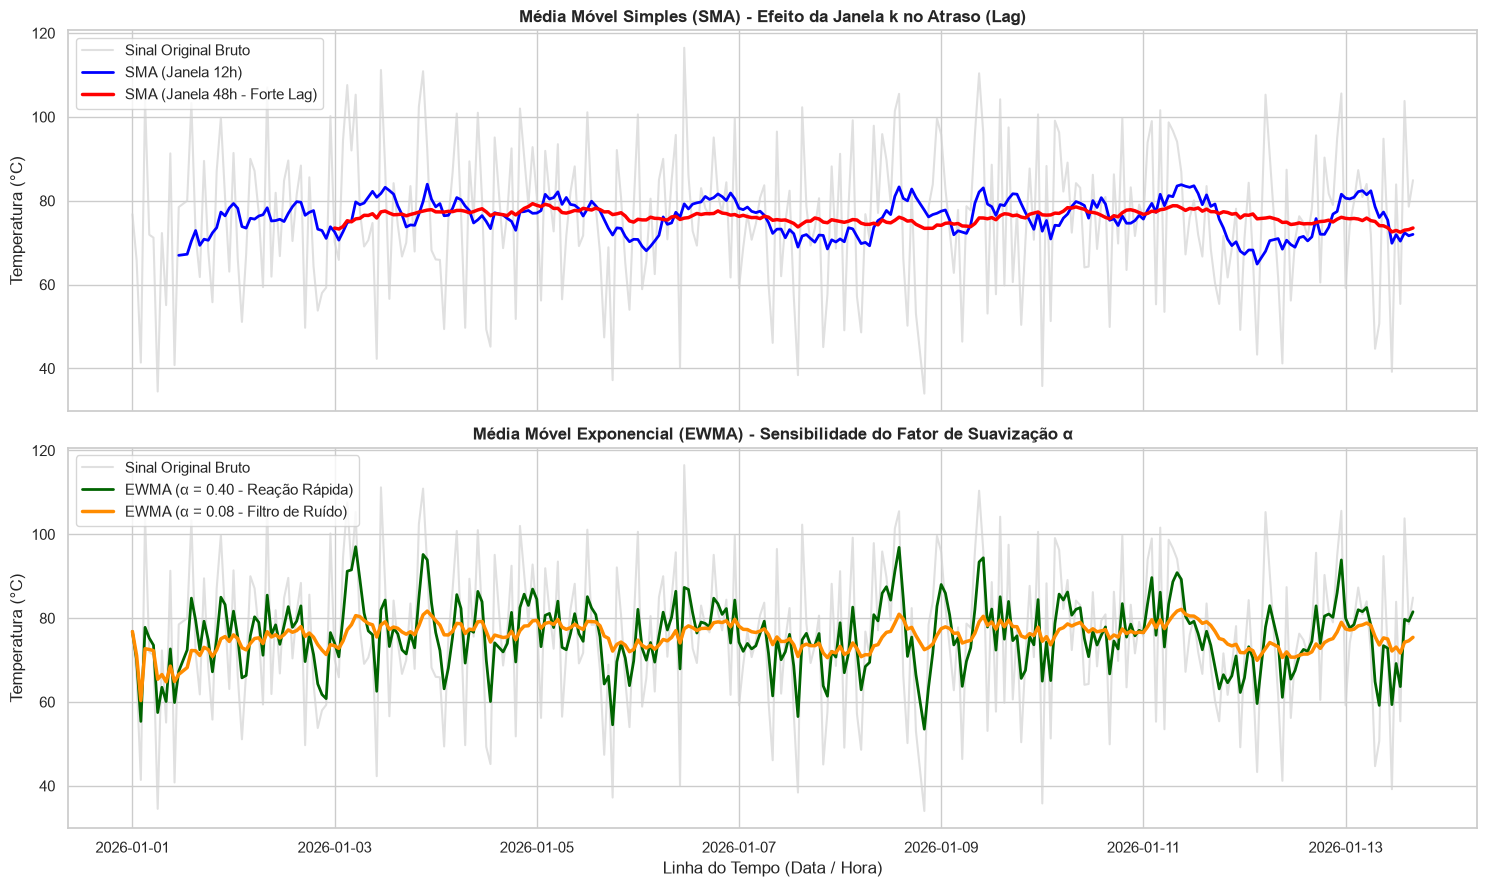

In [3]:
# =============================================================================
# ETAPA 3: Comparação de Médias Móveis: Simples (SMA) vs. Exponencial (EWMA)
# =============================================================================
sub_serie = serie_clean.iloc[:300].copy()

# 1. Cálculo da Média Móvel Simples (SMA)
sma_12h = sub_serie.rolling(window=12).mean()
sma_48h = sub_serie.rolling(window=48).mean()

# 2. Cálculo da Média Móvel Exponencial (EWMA)
ewma_alta = sub_serie.ewm(alpha=0.4).mean()   # Reação rápida (alpha = 0.4)
ewma_baixa = sub_serie.ewm(alpha=0.08).mean() # Suavização forte (alpha = 0.08)

# Visualização Comparativa em 2 Painéis
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Painel 1: Média Móvel Simples (SMA)
axes[0].plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.7, label='Sinal Original Bruto')
axes[0].plot(sma_12h.index, sma_12h.values, color='blue', lw=2, label='SMA (Janela 12h)')
axes[0].plot(sma_48h.index, sma_48h.values, color='red', lw=2.5, label='SMA (Janela 48h - Forte Lag)')
axes[0].set_title('Média Móvel Simples (SMA) - Efeito da Janela k no Atraso (Lag)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend(loc='upper left')

# Painel 2: Média Móvel Exponencial (EWMA)
axes[1].plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.7, label='Sinal Original Bruto')
axes[1].plot(ewma_alta.index, ewma_alta.values, color='darkgreen', lw=2, label='EWMA (α = 0.40 - Reação Rápida)')
axes[1].plot(ewma_baixa.index, ewma_baixa.values, color='darkorange', lw=2.5, label='EWMA (α = 0.08 - Filtro de Ruído)')
axes[1].set_title('Média Móvel Exponencial (EWMA) - Sensibilidade do Fator de Suavização α', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperatura (°C)')
axes[1].set_xlabel('Linha do Tempo (Data / Hora)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: Comparação entre Média Móvel Simples (SMA) e Exponencial (EWMA)

A comparação entre as técnicas de suavização no gráfico acima evidencia decisões críticas de projeto ao construir sistemas de **telemetria em tempo real**:

1. **Impacto da Média Móvel Simples (SMA)**:
   * **Janela Curta ($12\text{h}$)**: Filtra apenas pequenas variações de alta frequência, mantendo alta sensibilidade, porém ainda exibe oscilações indesejadas.
   * **Janela Longa ($48\text{h}$)**: Gera uma linha extremamente suave, contudo introduz um **atraso temporal (*lag*) severo**. Em um cenário industrial real, se o motor começar a sobreaquecer rapidamente devido a um travamento mecânico, a SMA de 48h demorará muitas horas para refletir o aumento térmico real, podendo atrasar o desligamento de emergência.

2. **Vantagem Operacional da Média Móvel Exponencial (EWMA)**:
   * **Sensibilidade Ajustável por $\alpha$**: A EWMA pondera a observação atual $y_t$ com peso $\alpha$ e o histórico acumulado com peso $(1 - \alpha)$.
   * **Reação Rápida ($\alpha = 0.40$)**: Responde prontamente a desvios recentes de temperatura sem o atraso pronunciado da SMA, sendo ideal para acionamento de alertas de segurança.
   * **Filtragem de Ruído ($\alpha = 0.08$)**: Elimina oscilações espúrias preservando o comportamento estrutural do processo.
   * **Conclusão**: A EWMA supera a SMA no monitoramento preditivo pois reage mais rápido às mudanças reais de estado do equipamento, eliminando simultaneamente falsos alarmes causados por ruídos estocásticos.


  ANÁLISE DE CONTROLE ESTATÍSTICO DE PROCESSO (CARTA EWMA)
• Média Histórica do Processo   : 75.17 °C
• Limite Superior de Controle  : 92.36 °C (LSC / UCL)
• Limite Inferior de Controle  : 57.98 °C (LIC / LCL)
• Número de Alertas de Anomalia : 0 eventos fora de controle


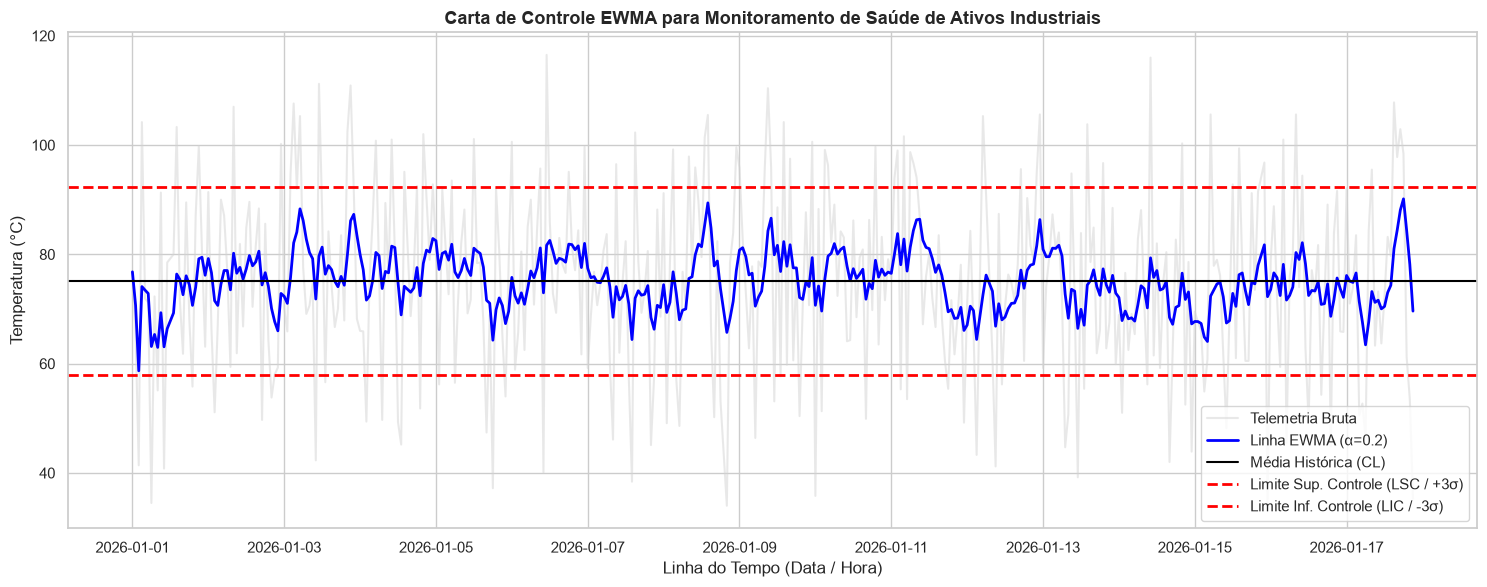

In [4]:
# =============================================================================
# ETAPA 4: Cartas de Controle EWMA e Alertas de Manutenção Preditiva
# =============================================================================
sub_serie = serie_clean.iloc[:400].copy()

# Parâmetros da Carta de Controle EWMA
alpha_controle = 0.20
ewma_serie = sub_serie.ewm(alpha=alpha_controle).mean()
media_historica = sub_serie.mean()
desvio_historico = sub_serie.std()

# Limites de Controle Estatístico (3 Sigmas)
# Variância assintótica da EWMA: sigma_ewma = sigma * sqrt(alpha / (2 - alpha))
sigma_ewma = desvio_historico * np.sqrt(alpha_controle / (2.0 - alpha_controle))
limite_superior = media_historica + (3.0 * sigma_ewma)
limite_inferior = media_historica - (3.0 * sigma_ewma)

# Identificação de Anomalias / Alarmes de Processo
anomalias = ewma_serie[(ewma_serie > limite_superior) | (ewma_serie < limite_inferior)]

print("=======================================================================")
print("  ANÁLISE DE CONTROLE ESTATÍSTICO DE PROCESSO (CARTA EWMA)")
print("=======================================================================")
print(f"• Média Histórica do Processo   : {media_historica:.2f} °C")
print(f"• Limite Superior de Controle  : {limite_superior:.2f} °C (LSC / UCL)")
print(f"• Limite Inferior de Controle  : {limite_inferior:.2f} °C (LIC / LCL)")
print(f"• Número de Alertas de Anomalia : {len(anomalias)} eventos fora de controle")
print("=======================================================================")

# Plotagem da Carta de Controle EWMA
plt.figure(figsize=(15, 6))
plt.plot(sub_serie.index, sub_serie.values, color='lightgray', alpha=0.5, label='Telemetria Bruta')
plt.plot(ewma_serie.index, ewma_serie.values, color='blue', lw=2, label=f'Linha EWMA (α={alpha_controle})')
plt.axhline(media_historica, color='black', linestyle='-', lw=1.5, label='Média Histórica (CL)')
plt.axhline(limite_superior, color='red', linestyle='--', lw=2, label='Limite Sup. Controle (LSC / +3σ)')
plt.axhline(limite_inferior, color='red', linestyle='--', lw=2, label='Limite Inf. Controle (LIC / -3σ)')

# Destaque dos Pontos de Alerta
if len(anomalias) > 0:
    plt.scatter(anomalias.index, anomalias.values, color='red', s=60, zorder=5, label='Alarme de Manutenção (Fora de Controle)')

plt.title('Carta de Controle EWMA para Monitoramento de Saúde de Ativos Industriais', fontsize=13, fontweight='bold')
plt.ylabel('Temperatura (°C)')
plt.xlabel('Linha do Tempo (Data / Hora)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
### Análise e Interpretação Didática: Cartas de Controle EWMA e Gestão de Anomalias

A Carta de Controle EWMA plotada acima é uma das ferramentas mais poderosas do **Controle Estatístico de Processos (CEP)** aplicado à Indústria 4.0:

1. **Estrutura dos Limites Estatísticos**:
   * **Linha Central (CL - *Center Line*)**: Representa a temperatura média histórica esperada do ativo em condições normais de operação ($\approx 75.17^\circ\text{C}$).
   * **Limites de Controle LSC e LIC ($\pm 3\sigma_{\text{ewma}}$)**: Definem a faixa de variação estatisticamente aceitável. Como a EWMA calcula a média ponderada, a sua variância é reduzida por um fator de $\sqrt{\frac{\alpha}{2 - \alpha}}$, tornando os limites mais estreitos e rigorosos em comparação com cartas de controle individuais convencionais.

2. **Diagnóstico de Saúde do Ativo**:
   * **Pontos Dentro dos Limites**: Indicação de que o processo fabril está sob controle estatístico (apenas variação natural e esperada).
   * **Eventos Fora de Controle (Pontos Vermelhos)**: Qualquer violação do Limite Superior ($> \text{LSC}$) indica uma **anomalia estatisticamente significativa**. No contexto de manutenção preditiva, isso sinaliza falhas emergentes (ex: lubrificação insuficiente, sobrecarga do motor ou contaminação de fluido hidráulico) antes mesmo que o equipamento atinja a temperatura crítica de colapso.


--- 
## 4. Exercícios de Fixação e Estudos Dirigidos

### Exercício 1: Identificação de Componentes de Séries Temporais
Em uma planta de usinagem CNC, registrou-se a corrente elétrica consumida por um motor ao longo de 6 meses. Observou-se um aumento gradual de 2 amperes a cada mês e picos diários de consumo durante o turno da tarde (14h-17h):
1. Qual padrão corresponde à **Tendência** e qual corresponde à **Sazonalidade**?
2. Em qual situação seria mais apropriado utilizar o **Modelo Multiplicativo** em vez do **Aditivo**?

--- 

### Exercício 2: Escolha do Fator de Suavização $\alpha$ na EWMA
Um engenheiro de confiabilidade deseja configurar uma carta de controle EWMA para monitorar o desgaste de uma ferramenta de corte:
1. Se o objetivo for detectar **mudanças abruptas e imediatas** no sinal de vibração, deve-se utilizar um $\alpha$ próximo de $0.9$ ou próximo de $0.05$? Justifique.
2. Qual a principal vantagem da EWMA sobre a Média Móvel Simples (SMA)?

--- 

### Exercício 3: Análise Prática no Dataset de Usinagem
Utilizando a coluna `pressao_hidraulica_bar` do dataset `CRISP_DM_Random_Forest_Usinagem_Qualidade.csv`:
1. Calcule a Média Móvel Simples (SMA) com janelas $k = 10$ e $k = 50$.
2. Calcule a EWMA com $\alpha = 0.15$.
3. Plote um gráfico comparativo e identifique em qual intervalo ocorreu a maior variação de pressão do sistema.

--- 

### Exercício 4: Diagnóstico de Resíduos
Após realizar a decomposição aditiva de uma série temporal de temperatura, aplicou-se o teste de Shapiro-Wilk sobre a componente de **Resíduos ($R_t$)**, obtendo-se $p \text{-valor} = 0.42$.
1. O que este resultado indica sobre a qualidade da decomposição e a presença de ruído branco?
